In this notebook, we demonstrate the application of 4D-Var on the Kolmogorov flow system, where the dynamical operator used to assimilate is a pre-trained neural operator, rather than a classical numerical simulator. This substitution allows for an important reduction of the computation cost, since the neural emulator allows for an accurate description of the system while operating with significantly coarsened spatial and temporal resolutions.

### To run this notebook, additional to adda environment, neuraloperator library version 0.3.0 must be installed!
https://github.com/neuraloperator/neuraloperator

In [1]:
import os
import torch
from matplotlib import pyplot as plt
from time import time
import numpy as np
from tensordict import TensorDict
# FNO emulator class.
from KF_Emulator.emulator import Emulator
os.chdir('..')
from adda.variational.strong_constraint_4dvar import sc4dvar_single_window, sc4dvar_sliding_window
from adda.system.state import State
from adda.observation.operators import random_sparse_noisy_obs
from adda.util.initialization import naive_initialization
from adda.probability.distributions import DiagonalGaussian
from adda.util.visualization import show_1dseqimg

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
torch.backends.cudnn.deterministic = True
torch.manual_seed(42)

cuda


## Loading the data from Disk

We load a single trajectory for data assimilation. This trajectory comes from the testing set of the emulator.

In [2]:
import h5py

# Open the HDF5 file
with h5py.File("notebooks/KF_Emulator/data_uv.h5", "r") as f:
    u = f["u"][:]      # shape (300, 32, 32)
    v = f["v"][:]      # shape (300, 32, 32)
    means = f["means"][:]  # shape (2,)
    stds = f["stds"][:]    # shape (2,)

# Normalize
u_norm = (u - means[0]) / stds[0]
v_norm = (v - means[1]) / stds[1]

# Stack along channel axis: (timesteps, 2, 32, 32)
uv_norm = np.stack([u_norm, v_norm], axis=1)

# Convert to torch tensor
uv_tensor = torch.from_numpy(uv_norm).float().to(device)
print(uv_tensor.shape)  # should be (300, 2, 32, 32)
num_timesteps, num_channels, height, width = uv_tensor.shape

torch.Size([300, 2, 32, 32])


## Loading and testing the trained Emulator's rollout performance

Due to its large size, the file 'network_weights.pth' containing the emulator weights is not available in the Github repository. It can be downloaded from Zenodo (https://zenodo.org/records/22127623), in the path indicated below.

In [3]:
trained_model_path = "notebooks/KF_Emulator/network_weights.pth"
ml_emulator = Emulator(trained_model_path).to(device)

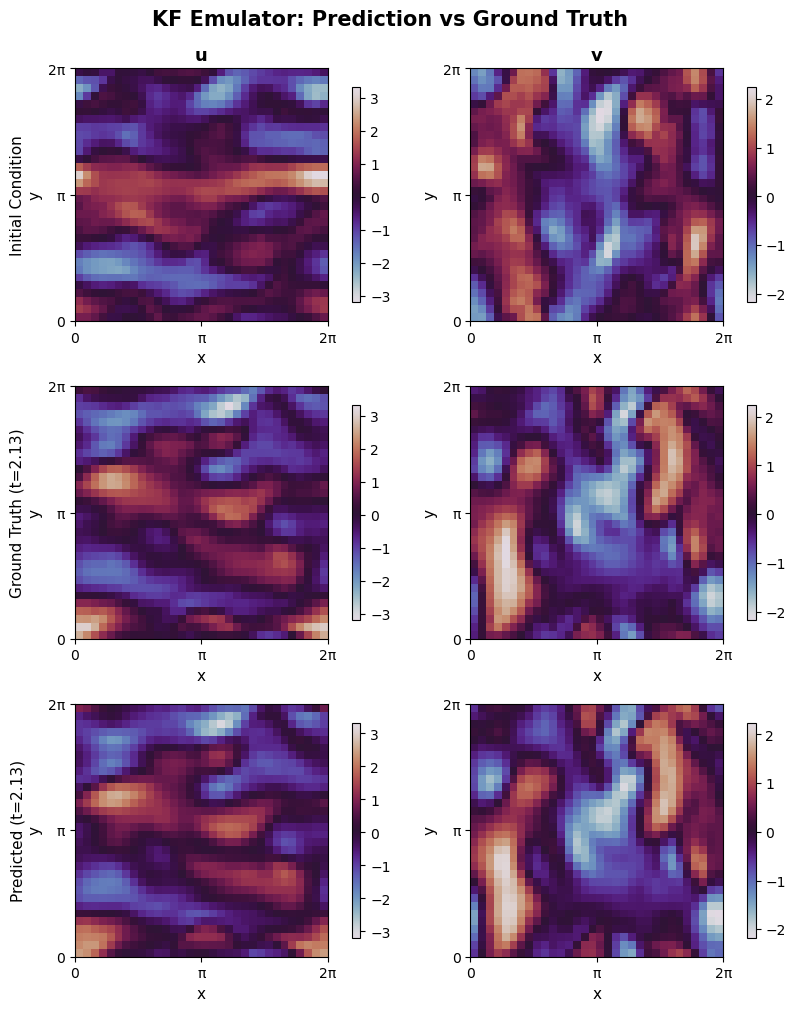

In [4]:
# It is an emulator with a fixed timestep and spatial resolution, therefore dt and dx don't matter but we will set it to the same value as the original simulation for plotting purposes.
dt = 0.133
dx = 2 * np.pi / 32
test_timesteps = 16
forecast_steps = torch.arange(0, test_timesteps * dt, dt)
ic = uv_tensor[0]
gt = uv_tensor[test_timesteps-1]  # shape (2, 32, 32)
network_input = ic.unsqueeze(0)  # shape (1, 2, 32, 32)

pred = ml_emulator.integrate(network_input, forecast_steps)
pred = pred.squeeze(0)  # shape (16, 2, 32, 32)

# Physical domain extent
Lx, Ly = 2 * np.pi, 2 * np.pi
extent = [0, Lx, 0, Ly]

# Consistent color ranges per variable
u_fields = [ic[0].cpu().numpy(), gt[0].cpu().numpy(), pred[test_timesteps-1][0].cpu().detach().numpy()]
v_fields = [ic[1].cpu().numpy(), gt[1].cpu().numpy(), pred[test_timesteps-1][1].cpu().detach().numpy()]
u_vmin, u_vmax = min(f.min() for f in u_fields), max(f.max() for f in u_fields)
v_vmin, v_vmax = min(f.min() for f in v_fields), max(f.max() for f in v_fields)

cmap = 'twilight'
row_labels = ['Initial Condition', f'Ground Truth (t={test_timesteps*dt:.2f})', f'Predicted (t={test_timesteps*dt:.2f})']
data = [[u_fields[i], v_fields[i]] for i in range(3)]
vlims = [(u_vmin, u_vmax), (v_vmin, v_vmax)]

fig, ax = plt.subplots(3, 2, figsize=(8, 10), constrained_layout=True)
fig.suptitle('KF Emulator: Prediction vs Ground Truth', fontsize=15, fontweight='bold')

for i in range(3):
    for j, var in enumerate(['u', 'v']):
        im = ax[i, j].imshow(
            data[i][j], cmap=cmap, extent=extent, origin='lower',
            vmin=vlims[j][0], vmax=vlims[j][1],
        )
        ax[i, j].set_xlabel('x', fontsize=11)
        ax[i, j].set_ylabel('y', fontsize=11)
        ax[i, j].set_xticks([0, np.pi, 2*np.pi])
        ax[i, j].set_xticklabels(['0', 'π', '2π'])
        ax[i, j].set_yticks([0, np.pi, 2*np.pi])
        ax[i, j].set_yticklabels(['0', 'π', '2π'])
        if i == 0:
            ax[i, j].set_title(var, fontsize=13, fontweight='bold')
        fig.colorbar(im, ax=ax[i, j], shrink=0.85)
    # Row label on the left
    ax[i, 0].set_ylabel(f'{row_labels[i]}\ny', fontsize=11)

plt.show()

In [5]:
tot_timesteps = uv_tensor.shape[0]
forecast_steps = torch.arange(0, tot_timesteps * dt, dt)
true_series = State(uv_tensor.unsqueeze(0), time_axis=forecast_steps)

## Strong-constraint 4D-var

In [6]:
noise_amplitude = 1.0  # observation noise s.d.
p_obs = 0.05 # 95% of the variables are masked

groundtruth, obs_op, observations = random_sparse_noisy_obs(true_series, noise_amplitude, p_obs)

In [7]:
n_obs_steps = 32 # we assimilate only on the earliest time steps for the single window strong constraint 4D-Var, otherwise the optimization would be too unstable.
time_window = (observations.state.time_axis[0], observations.state.time_axis[n_obs_steps])
obs_op_opt = obs_op.restrict_time_domain(*time_window)
observations_opt = observations.restrict_time_domain(*time_window)

### Visualization of the Noisy Observations

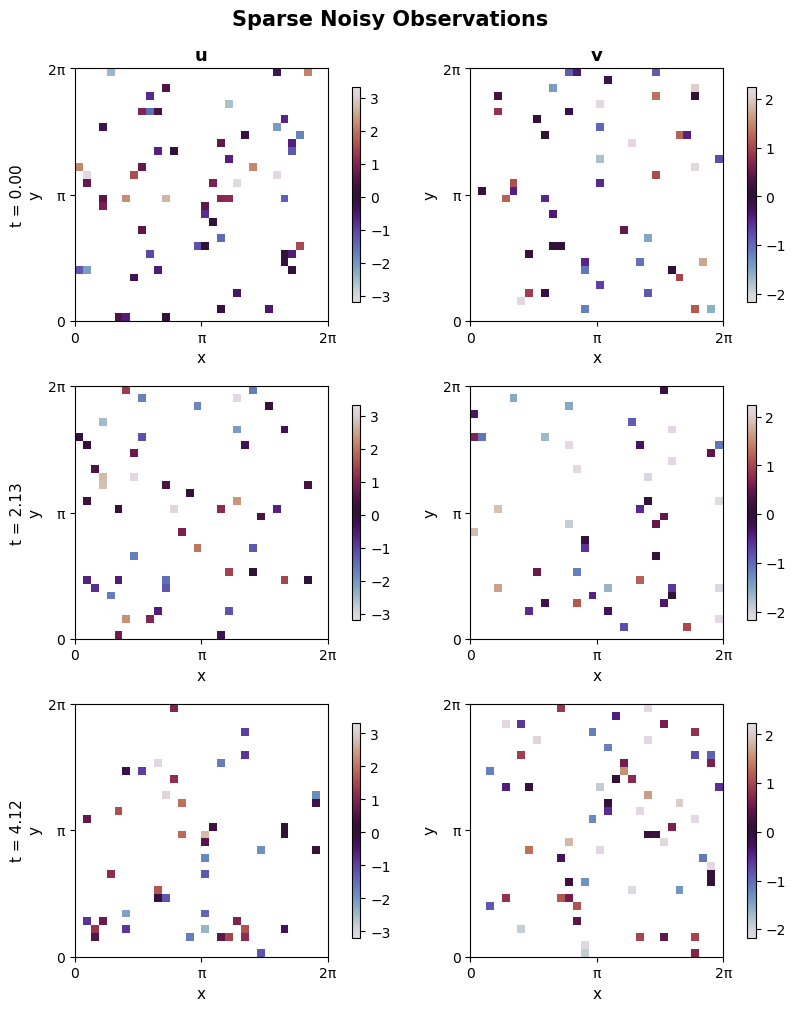

In [8]:
times = [0, n_obs_steps // 2, n_obs_steps-1]
cmap = 'twilight'

obs_u = [observations.state.fields['x'][0, t, 0].detach().cpu().numpy() for t in times]
obs_v = [observations.state.fields['x'][0, t, 1].detach().cpu().numpy() for t in times]
data = [[obs_u[i], obs_v[i]] for i in range(3)]
row_labels = [f't = {times[i] * dt:.2f}' for i in range(3)]

fig, ax = plt.subplots(3, 2, figsize=(8, 10), constrained_layout=True)
fig.suptitle('Sparse Noisy Observations', fontsize=15, fontweight='bold')

for i in range(3):
    for j, var in enumerate(['u', 'v']):
        im = ax[i, j].imshow(
            data[i][j], cmap=cmap, extent=extent, origin='lower',
            vmin=vlims[j][0], vmax=vlims[j][1],
        )
        ax[i, j].set_xlabel('x', fontsize=11)
        ax[i, j].set_ylabel('y', fontsize=11)
        ax[i, j].set_xticks([0, np.pi, 2*np.pi])
        ax[i, j].set_xticklabels(['0', 'π', '2π'])
        ax[i, j].set_yticks([0, np.pi, 2*np.pi])
        ax[i, j].set_yticklabels(['0', 'π', '2π'])
        if i == 0:
            ax[i, j].set_title(var, fontsize=13, fontweight='bold')
        fig.colorbar(im, ax=ax[i, j], shrink=0.85)
    ax[i, 0].set_ylabel(f'{row_labels[i]}\ny', fontsize=11)

plt.show()

In [9]:
# In order to use the 4D-Var function, you should always have a function like this taking the state, dt, dynamic_inputs and static_inputs
def next_step_function(x: State, dt: float, dynamic_inputs: State, static_inputs: State):
    B, T = x.fields.batch_size[:2]
    input = x.fields["x"].reshape(B * T, num_channels, height, width)
    # print("input.shape:", input.shape)  # should be (B*T, 2, 32, 32)
    integrated = ml_emulator.integrate(input, torch.arange(2) * dt)[:, -2:-1] # integrate over a time step, take the current time
    # print("integrated.shape:", integrated.shape)  # should be (B*T, 1, 2, 32, 32)
    integrated = integrated.reshape(B, T, num_channels, height, width)
    # print("integrated.shape after reshape:", integrated.shape)  # should be (B, T, 2, 32, 32)
    new_fields = TensorDict(x=integrated, batch_size=(B, T))
    return State(new_fields, time_axis=x.time_axis + dt)  # return State object, advancing time

In [10]:
initialization = naive_initialization(observations_opt, default_value=0) # naive initialization on the firt time step of the time series
initialization = initialization[:, :1] # we only initialize the first time step, the rest will be optimized

In [11]:
t0 = time()
assimilated_ic = sc4dvar_single_window(next_step_function, 
                                       observations_opt,
                                       obs_op_opt, 
                                       initialization,
                                       optimizer_class=torch.optim.Adam,
                                       optimizer_pars={'lr': 5e-3},
                                       scheduler_class=torch.optim.lr_scheduler.CyclicLR,
                                       scheduler_pars={'base_lr': 2e-3, 'max_lr': 5e-3, 'step_size_up': 10},
                                       n_steps=100,
                                       verbose=1
                                       )                                     
print(f'Total time for the 4D-Var optimization: {time() - t0} seconds')

iteration 0: loss = 5630.5380859375
iteration 0: lr = 0.0023000000000000004
iteration 1: loss = 5577.962890625
iteration 1: lr = 0.0026000000000000007
iteration 2: loss = 5524.7861328125
iteration 2: lr = 0.0028999999999999994
iteration 3: loss = 5471.451171875
iteration 3: lr = 0.0031999999999999997
iteration 4: loss = 5417.08154296875
iteration 4: lr = 0.0035
iteration 5: loss = 5359.79541015625
iteration 5: lr = 0.0038000000000000004
iteration 6: loss = 5297.505859375
iteration 6: lr = 0.004100000000000001
iteration 7: loss = 5229.65185546875
iteration 7: lr = 0.004399999999999999
iteration 8: loss = 5153.28515625
iteration 8: lr = 0.004699999999999999
iteration 9: loss = 5061.9794921875
iteration 9: lr = 0.005
iteration 10: loss = 4977.6806640625
iteration 10: lr = 0.004699999999999999
iteration 11: loss = 4915.763671875
iteration 11: lr = 0.004399999999999999
iteration 12: loss = 4846.16064453125
iteration 12: lr = 0.004100000000000001
iteration 13: loss = 4775.79296875
iteration 

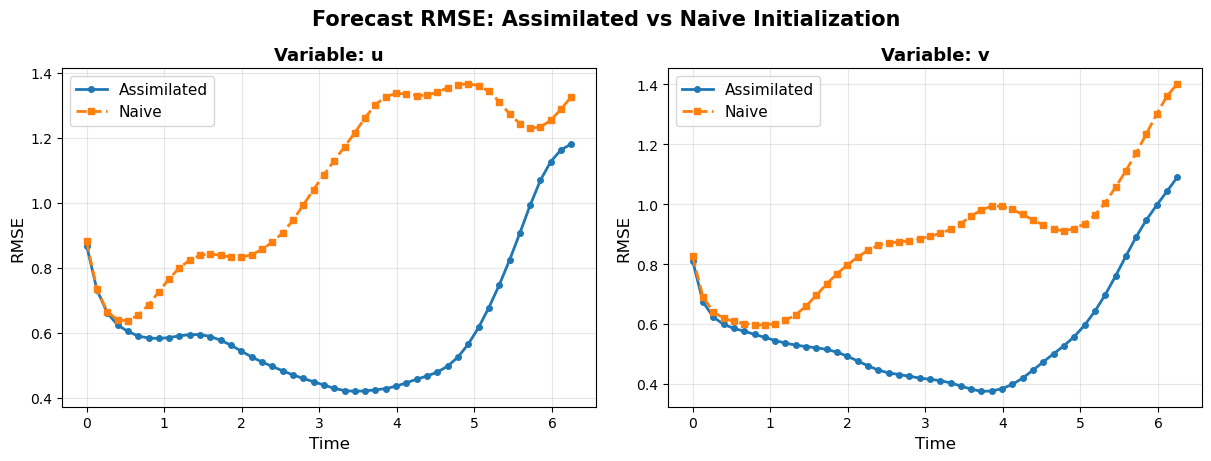

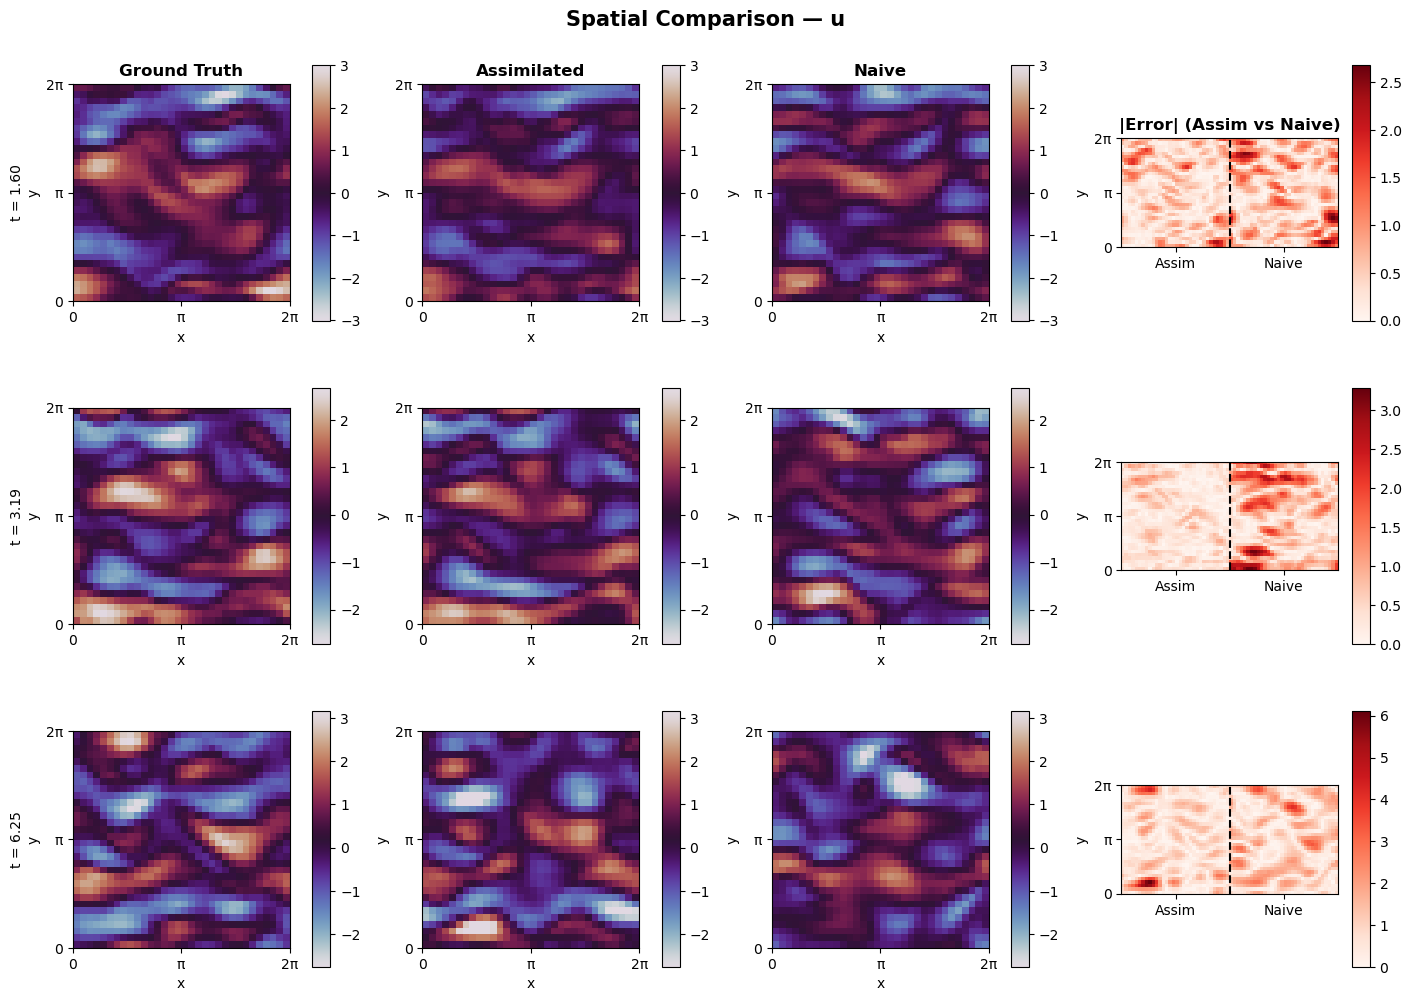

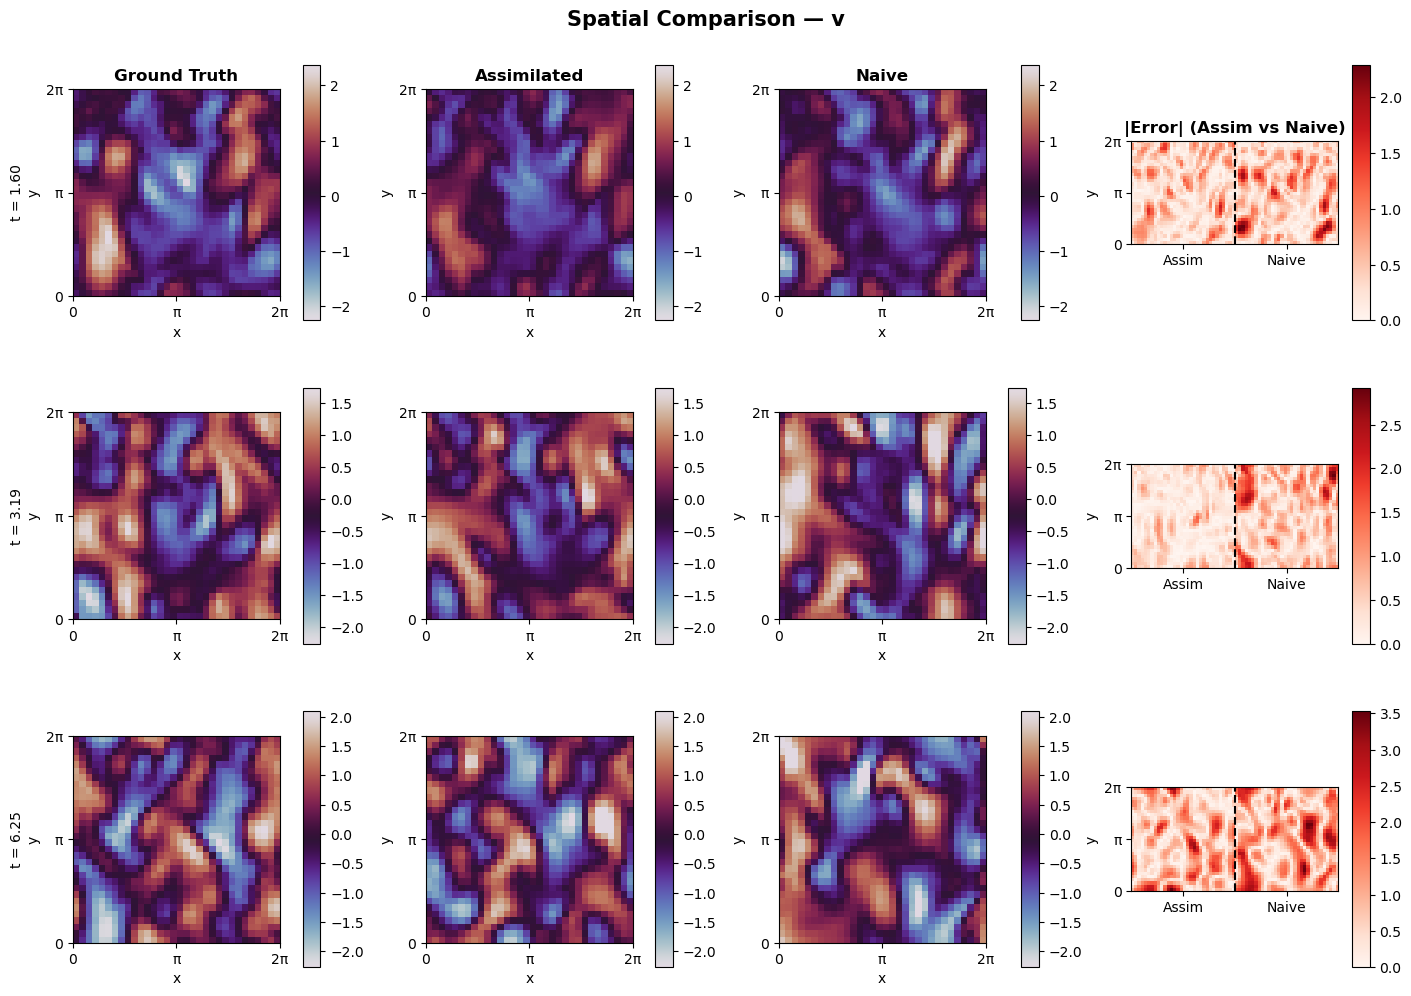

Metric                     Assimilated IC        Naive IC
---------------------------------------------------------
Mean RMSE (u)                      0.6129          1.0582
Mean RMSE (v)                      0.5681          0.8842
Final RMSE (u)                     1.1819          1.3272
Final RMSE (v)                     1.0912          1.4021


In [12]:
n_forecast = 48
forecast_steps_eval = torch.arange(0, n_forecast * dt, dt)

# Forecast from assimilated IC
assim_ic = assimilated_ic.fields['x'].squeeze().detach()  # (2, 32, 32)
pred_assim = ml_emulator.integrate(assim_ic.unsqueeze(0), forecast_steps_eval).squeeze(0)  # (n_forecast, 2, 32, 32)

# Forecast from naive initialization
naive_ic = initialization.fields['x'].squeeze().detach()  # (2, 32, 32)
pred_naive = ml_emulator.integrate(naive_ic.unsqueeze(0), forecast_steps_eval).squeeze(0)  # (n_forecast, 2, 32, 32)

gt_window = uv_tensor[:n_forecast]  # (n_forecast, 2, 32, 32)

def rmse_over_time(pred, gt):
    """Compute spatial RMSE at each timestep for u and v."""
    diff = (pred.detach() - gt).cpu().numpy()
    # diff shape: (T, 2, H, W)
    rmse_u = np.sqrt((diff[:, 0] ** 2).mean(axis=(1, 2)))
    rmse_v = np.sqrt((diff[:, 1] ** 2).mean(axis=(1, 2)))
    return rmse_u, rmse_v

rmse_assim_u, rmse_assim_v = rmse_over_time(pred_assim, gt_window)
rmse_naive_u, rmse_naive_v = rmse_over_time(pred_naive, gt_window)
time_axis = np.arange(n_forecast) * dt

# Plot 1: RMSE over time
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
fig.suptitle('Forecast RMSE: Assimilated vs Naive Initialization', fontsize=15, fontweight='bold')

for ax, rmse_a, rmse_n, var in zip(axes, [rmse_assim_u, rmse_assim_v], [rmse_naive_u, rmse_naive_v], ['u', 'v']):
    ax.plot(time_axis, rmse_a, 'o-', label='Assimilated', linewidth=2, markersize=4)
    ax.plot(time_axis, rmse_n, 's--', label='Naive', linewidth=2, markersize=4)
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('RMSE', fontsize=12)
    ax.set_title(f'Variable: {var}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
plt.show()

# Plot 2: Spatial comparison at 3 time snapshots
snap_times = [n_forecast // 4, n_forecast // 2, n_forecast - 1]
cmap = 'twilight'
cmap_err = 'Reds'

for ch, var in enumerate(['u', 'v']):
    fig, ax = plt.subplots(3, 4, figsize=(14, 10), constrained_layout=True)
    fig.suptitle(f'Spatial Comparison — {var}', fontsize=15, fontweight='bold')
    col_titles = ['Ground Truth', 'Assimilated', 'Naive', '|Error| (Assim vs Naive)']
    for j, title in enumerate(col_titles):
        ax[0, j].set_title(title, fontsize=12, fontweight='bold')

    for i, t in enumerate(snap_times):
        gt_field = gt_window[t, ch].cpu().numpy()
        assim_field = pred_assim[t, ch].cpu().detach().numpy()
        naive_field = pred_naive[t, ch].cpu().detach().numpy()
        err_assim = np.abs(assim_field - gt_field)
        err_naive = np.abs(naive_field - gt_field)
        err_max = max(err_assim.max(), err_naive.max())

        vmin, vmax = gt_field.min(), gt_field.max()

        for j, field in enumerate([gt_field, assim_field, naive_field]):
            im = ax[i, j].imshow(field, cmap=cmap, extent=extent, origin='lower', vmin=vmin, vmax=vmax)
            fig.colorbar(im, ax=ax[i, j], shrink=0.85)
        err_combined = np.concatenate([err_assim, err_naive], axis=1)
        im = ax[i, 3].imshow(err_combined, cmap=cmap_err, extent=[0, 2*Lx, 0, Ly], origin='lower', vmin=0, vmax=err_max)
        ax[i, 3].axvline(Lx, color='k', linewidth=1.5, linestyle='--')
        ax[i, 3].set_xticks([Lx/2, 3*Lx/2])
        ax[i, 3].set_xticklabels(['Assim', 'Naive'], fontsize=10)
        fig.colorbar(im, ax=ax[i, 3], shrink=0.85)

        for j in range(4):
            if j < 3:
                ax[i, j].set_xticks([0, np.pi, 2*np.pi])
                ax[i, j].set_xticklabels(['0', 'π', '2π'])
                ax[i, j].set_yticks([0, np.pi, 2*np.pi])
                ax[i, j].set_yticklabels(['0', 'π', '2π'])
                ax[i, j].set_xlabel('x', fontsize=10)
            ax[i, j].set_ylabel(f't = {t*dt:.2f}\ny' if j == 0 else 'y', fontsize=10)
            if j == 3:
                ax[i, j].set_yticks([0, np.pi, 2*np.pi])
                ax[i, j].set_yticklabels(['0', 'π', '2π'])

    plt.show()

# Summary
print(f"{'Metric':<25} {'Assimilated IC':>15} {'Naive IC':>15}")
print("-" * 57)
print(f"{'Mean RMSE (u)':<25} {rmse_assim_u.mean():>15.4f} {rmse_naive_u.mean():>15.4f}")
print(f"{'Mean RMSE (v)':<25} {rmse_assim_v.mean():>15.4f} {rmse_naive_v.mean():>15.4f}")
print(f"{'Final RMSE (u)':<25} {rmse_assim_u[-1]:>15.4f} {rmse_naive_u[-1]:>15.4f}")
print(f"{'Final RMSE (v)':<25} {rmse_assim_v[-1]:>15.4f} {rmse_naive_v[-1]:>15.4f}")

## Sliding Window Strong-constraint 4D-var

In [13]:
noise_amplitude = 1.0  # observation noise s.d.
p_obs = 0.05 # 95% of the variables are masked

groundtruth, obs_op, observations = random_sparse_noisy_obs(true_series, noise_amplitude, p_obs)

In [14]:
n_obs_steps = 64 # we can have a longer window here since we'll use sliding windows.
time_window = (observations.state.time_axis[0], observations.state.time_axis[n_obs_steps])
obs_op_opt = obs_op.restrict_time_domain(*time_window)
observations_opt = observations.restrict_time_domain(*time_window)

In [15]:
print(initialization.fields['x'].shape)
# Background prior for the start of the windows.
background_prior = DiagonalGaussian(initialization.fields['x'].to(device), 
                                    torch.ones(1, 1, 2, height, width, device=device) * 2 * noise_amplitude)

torch.Size([1, 1, 2, 32, 32])


In [16]:
# We choose window duration of 8.
window_duration = 8
window_shift = 1.0
t0 = time()
assimilated_ic = sc4dvar_sliding_window(next_step_function, 
                                        observations_opt,
                                        obs_op_opt,
                                        window_duration=window_duration,
                                        window_shift=window_shift,
                                        x_init=initialization,
                                        background_prior=background_prior,
                                        optimizer_class=torch.optim.Adam,
                                        optimizer_pars={'lr': 2e-3},
                                        scheduler_class=torch.optim.lr_scheduler.CyclicLR,
                                        scheduler_pars={'base_lr': 2e-3, 'max_lr': 5e-3, 'step_size_up': 10},
                                        n_steps=100,
                                        verbose=1
                                        )                                     
print(f'Total time for the 4D-Var optimization: {time() - t0} seconds')

/work/gg0028/g260231/Repos/da-tools/adda/variational/base.py:44: UserWarning: using float32 for state time axis can lead to precision issues when checking for fixed dt in long sequences. HINT: try generating and providing time tensor using double precision if shape mismatch assertion presents.
  warnings.warn(


Time steps 0 to 8
iteration 0: loss = 1336.221923828125
iteration 0: lr = 0.0023000000000000004
iteration 1: loss = 1332.0753173828125
iteration 1: lr = 0.0026000000000000007
iteration 2: loss = 1327.55615234375
iteration 2: lr = 0.0028999999999999994
iteration 3: loss = 1322.6572265625
iteration 3: lr = 0.0031999999999999997
iteration 4: loss = 1317.3634033203125
iteration 4: lr = 0.0035
iteration 5: loss = 1311.662353515625
iteration 5: lr = 0.0038000000000000004
iteration 6: loss = 1305.4931640625
iteration 6: lr = 0.004100000000000001
iteration 7: loss = 1298.9000244140625
iteration 7: lr = 0.004399999999999999
iteration 8: loss = 1291.9051513671875
iteration 8: lr = 0.004699999999999999
iteration 9: loss = 1284.3985595703125
iteration 9: lr = 0.005
iteration 10: loss = 1276.42138671875
iteration 10: lr = 0.004699999999999999
iteration 11: loss = 1267.9376220703125
iteration 11: lr = 0.004399999999999999
iteration 12: loss = 1259.8760986328125
iteration 12: lr = 0.00410000000000000

In [17]:
# Now we can forecast from the assimilated ICs obtained at the start of each window, and stitch the forecasts together to get a forecast over the entire time series.
from adda.util.state_space import rollout

n_steps_per_window = n_obs_steps // window_duration

with torch.no_grad():
    predictions_list = []
    for k in range(n_obs_steps // n_steps_per_window):
        prediction_partial = rollout(next_step_function, 
                                     forecast_steps[k*n_steps_per_window : (k+1)*n_steps_per_window], 
                                     assimilated_ic[0][k])
        prediction_partial.fields = prediction_partial.fields.to('cpu')
        prediction_partial.fields = prediction_partial.fields.to(torch.float16)
        predictions_list.append(prediction_partial.clone())
    predictions_td = TensorDict(x=torch.cat([prediction.fields['x'] for prediction in predictions_list], axis=1))
    predictions = State(predictions_td, forecast_steps[0:n_obs_steps])

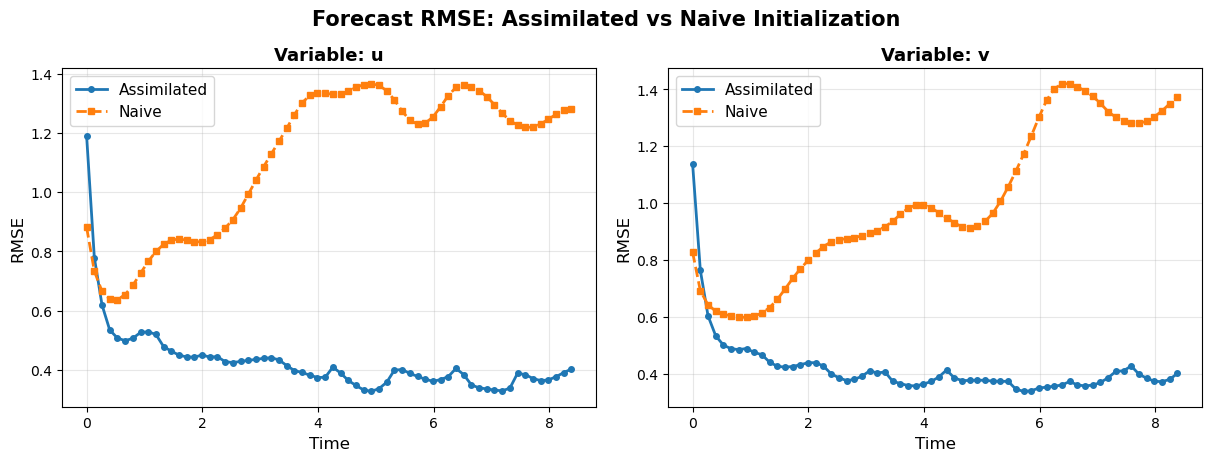

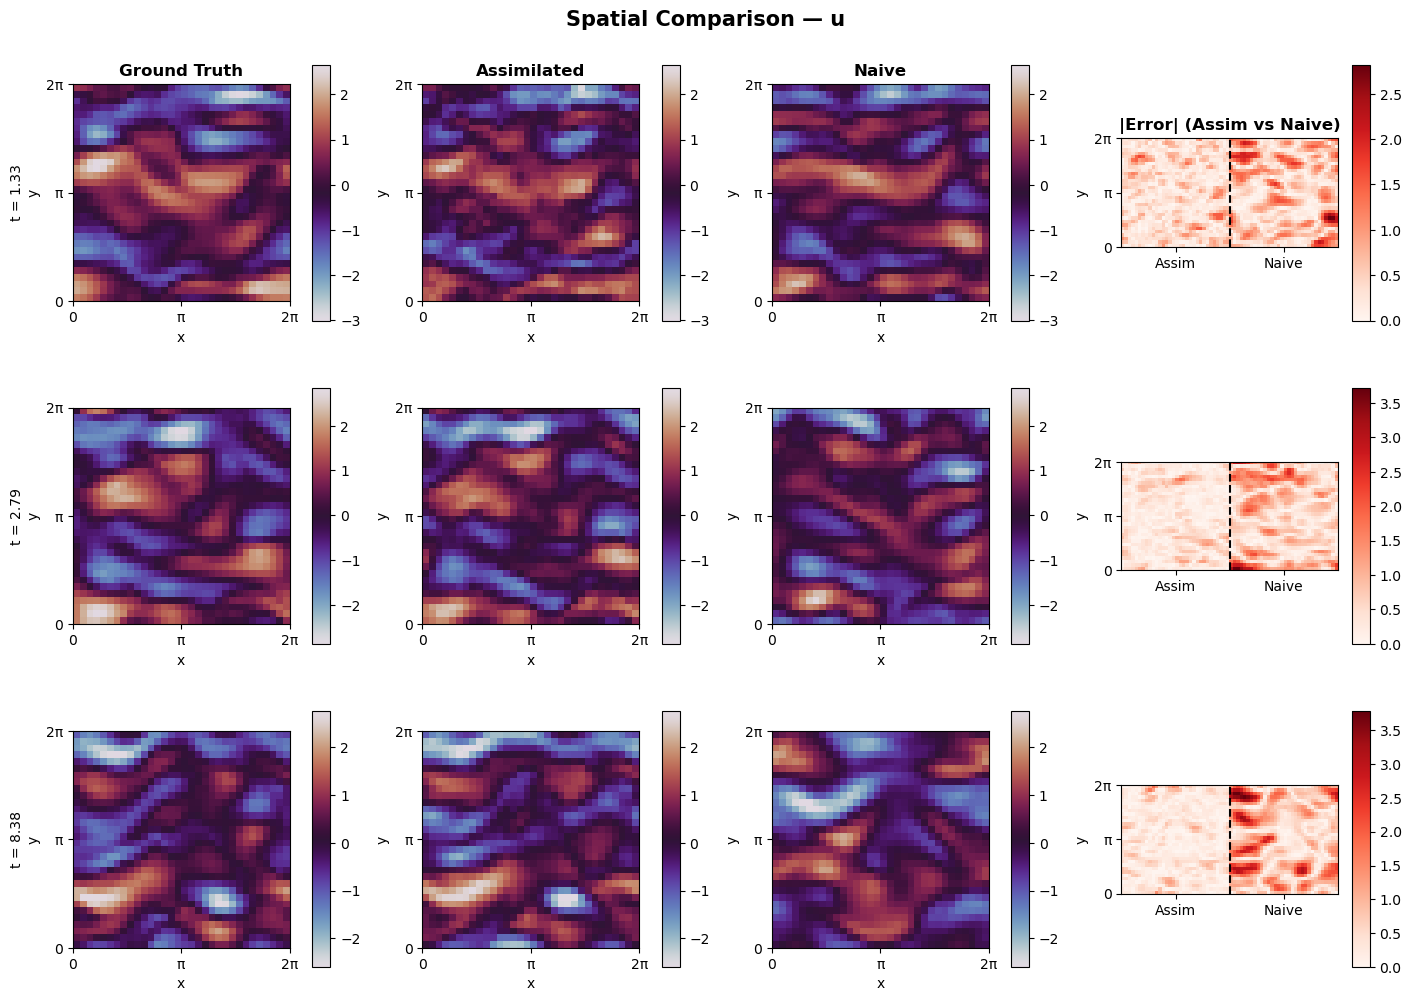

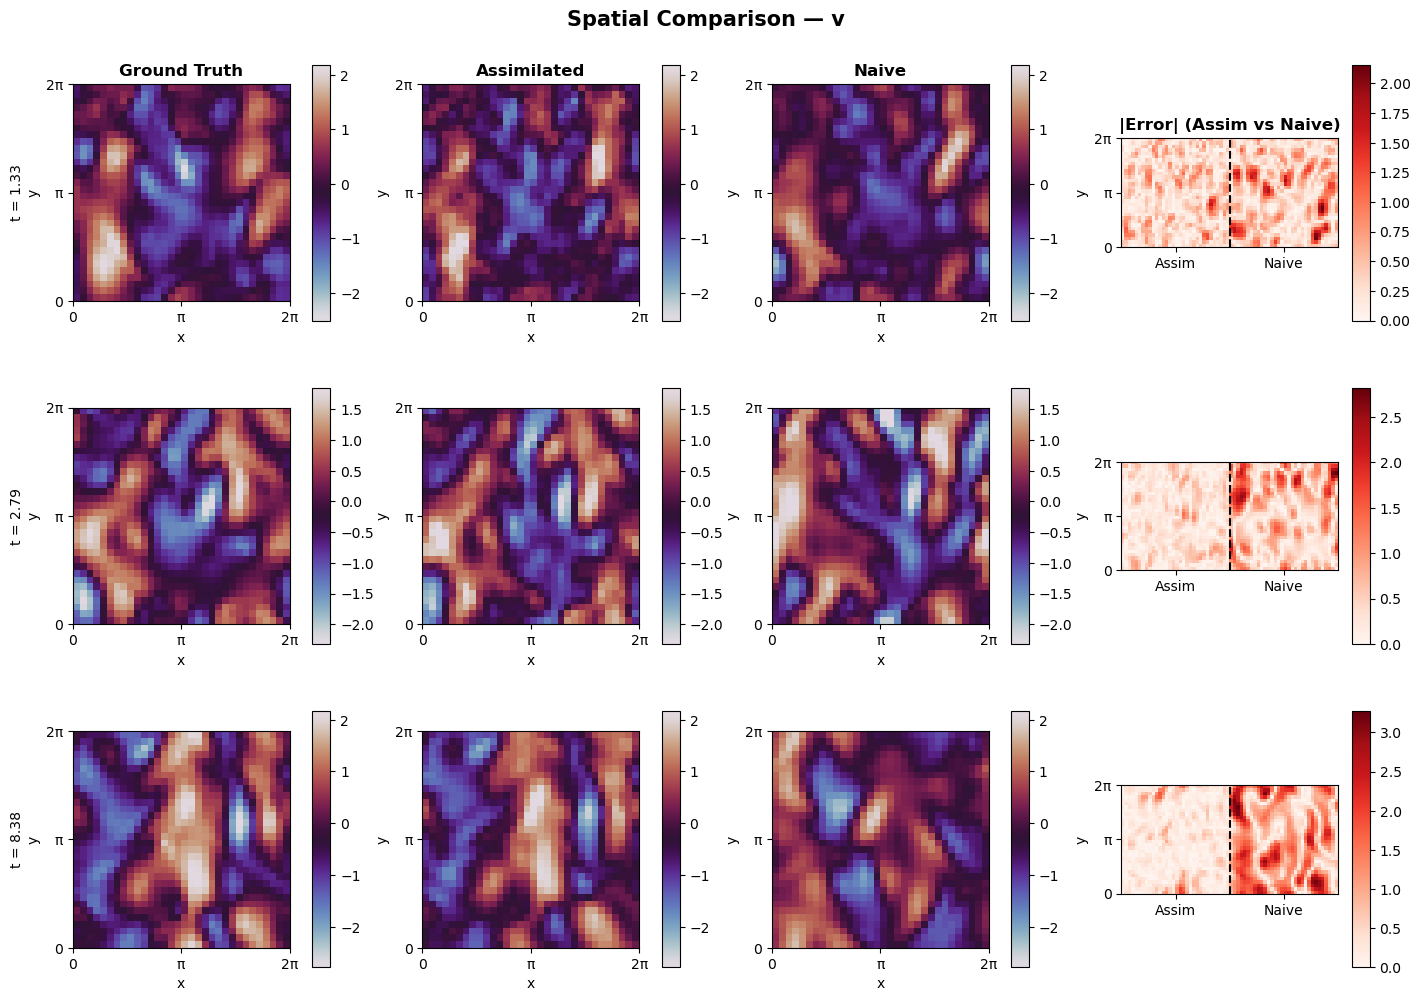

Metric                        Assimilated           Naive
---------------------------------------------------------
Mean RMSE (u)                      0.4277          1.1142
Mean RMSE (v)                      0.4176          0.9989
Final RMSE (u)                     0.4027          1.2824
Final RMSE (v)                     0.4010          1.3744


In [18]:
forecast_steps_eval = torch.arange(0, n_obs_steps * dt, dt)

# Assimilated predictions from rollout above
pred_assim = predictions.fields['x'].squeeze(0).detach().cpu().float()  # (num_timesteps, 2, 32, 32)

# Forecast from naive initialization
naive_ic = initialization.fields['x'].squeeze().detach()  # (2, 32, 32)
pred_naive = ml_emulator.integrate(naive_ic.unsqueeze(0), forecast_steps_eval).squeeze(0).cpu()  # (num_timesteps, 2, 32, 32)

# Ground truth for the same window
gt_window = uv_tensor[:n_obs_steps].cpu()  # (num_timesteps, 2, 32, 32)


rmse_assim_u, rmse_assim_v = rmse_over_time(pred_assim, gt_window)
rmse_naive_u, rmse_naive_v = rmse_over_time(pred_naive, gt_window)
time_axis = np.arange(n_obs_steps) * dt

# Plot 1: RMSE over time
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
fig.suptitle('Forecast RMSE: Assimilated vs Naive Initialization', fontsize=15, fontweight='bold')

for ax, rmse_a, rmse_n, var in zip(axes, [rmse_assim_u, rmse_assim_v], [rmse_naive_u, rmse_naive_v], ['u', 'v']):
    ax.plot(time_axis, rmse_a, 'o-', label='Assimilated', linewidth=2, markersize=4)
    ax.plot(time_axis, rmse_n, 's--', label='Naive', linewidth=2, markersize=4)
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('RMSE', fontsize=12)
    ax.set_title(f'Variable: {var}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
plt.show()

# Plot 2: Spatial comparison at 3 time snapshots
snap_times = [n_obs_steps // 6, n_obs_steps // 3, n_obs_steps - 1]
cmap = 'twilight'
cmap_err = 'Reds'

for ch, var in enumerate(['u', 'v']):
    fig, ax = plt.subplots(3, 4, figsize=(14, 10), constrained_layout=True)
    fig.suptitle(f'Spatial Comparison — {var}', fontsize=15, fontweight='bold')
    col_titles = ['Ground Truth', 'Assimilated', 'Naive', '|Error| (Assim vs Naive)']
    for j, title in enumerate(col_titles):
        ax[0, j].set_title(title, fontsize=12, fontweight='bold')

    for i, t in enumerate(snap_times):
        gt_field = gt_window[t, ch].numpy()
        assim_field = pred_assim[t, ch].detach().numpy()
        naive_field = pred_naive[t, ch].detach().numpy()
        err_assim = np.abs(assim_field - gt_field)
        err_naive = np.abs(naive_field - gt_field)
        err_max = max(err_assim.max(), err_naive.max())

        vmin, vmax = gt_field.min(), gt_field.max()

        for j, field in enumerate([gt_field, assim_field, naive_field]):
            im = ax[i, j].imshow(field, cmap=cmap, extent=extent, origin='lower', vmin=vmin, vmax=vmax)
            fig.colorbar(im, ax=ax[i, j], shrink=0.85)
        err_combined = np.concatenate([err_assim, err_naive], axis=1)
        im = ax[i, 3].imshow(err_combined, cmap=cmap_err, extent=[0, 2*Lx, 0, Ly], origin='lower', vmin=0, vmax=err_max)
        ax[i, 3].axvline(Lx, color='k', linewidth=1.5, linestyle='--')
        ax[i, 3].set_xticks([Lx/2, 3*Lx/2])
        ax[i, 3].set_xticklabels(['Assim', 'Naive'], fontsize=10)
        fig.colorbar(im, ax=ax[i, 3], shrink=0.85)

        for j in range(4):
            if j < 3:
                ax[i, j].set_xticks([0, np.pi, 2*np.pi])
                ax[i, j].set_xticklabels(['0', 'π', '2π'])
                ax[i, j].set_yticks([0, np.pi, 2*np.pi])
                ax[i, j].set_yticklabels(['0', 'π', '2π'])
                ax[i, j].set_xlabel('x', fontsize=10)
            ax[i, j].set_ylabel(f't = {t*dt:.2f}\ny' if j == 0 else 'y', fontsize=10)
            if j == 3:
                ax[i, j].set_yticks([0, np.pi, 2*np.pi])
                ax[i, j].set_yticklabels(['0', 'π', '2π'])

    plt.show()

# Summary
print(f"{'Metric':<25} {'Assimilated':>15} {'Naive':>15}")
print("-" * 57)
print(f"{'Mean RMSE (u)':<25} {rmse_assim_u.mean():>15.4f} {rmse_naive_u.mean():>15.4f}")
print(f"{'Mean RMSE (v)':<25} {rmse_assim_v.mean():>15.4f} {rmse_naive_v.mean():>15.4f}")
print(f"{'Final RMSE (u)':<25} {rmse_assim_u[-1]:>15.4f} {rmse_naive_u[-1]:>15.4f}")
print(f"{'Final RMSE (v)':<25} {rmse_assim_v[-1]:>15.4f} {rmse_naive_v[-1]:>15.4f}")

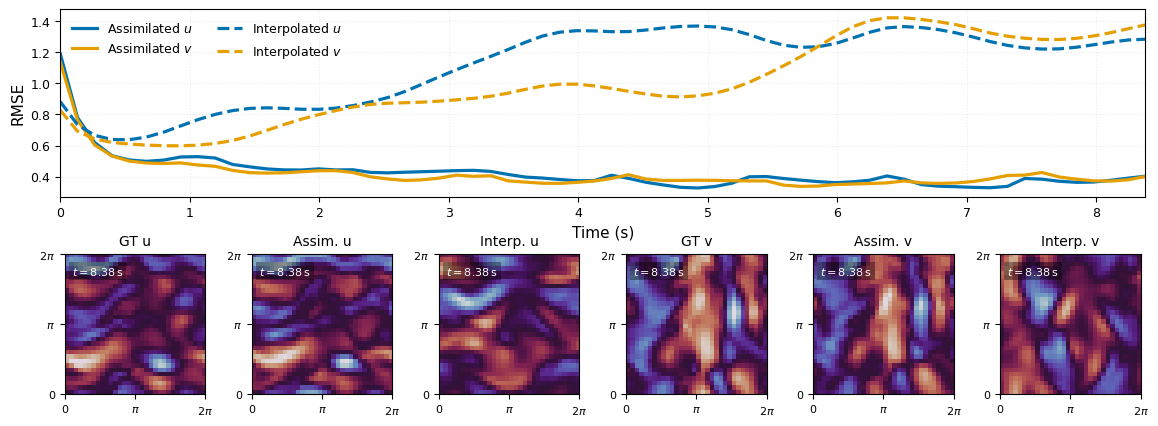

In [22]:
fig = plt.figure(figsize=(14, 5))

gs = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[1.0, 0.75],
    hspace=0.35,
)
ax = fig.add_subplot(gs[0, 0])
curves = [
    (rmse_assim_u, "#0072B2", "-", r"Assimilated $u$"),
    (rmse_assim_v, "#E69F00", "-", r"Assimilated $v$"),
    (rmse_naive_u, "#0072B2", "--", r"Interpolated $u$"),
    (rmse_naive_v, "#E69F00", "--", r"Interpolated $v$"),
]
terminal_time_idx = snap_times[-1]
terminal_time = forecast_steps_eval[-1]
for rmse, color, linestyle, label in curves:
    ax.plot(
        time_axis,
        rmse,
        color=color,
        linestyle=linestyle,
        linewidth=2.3,
        label=label,
    )

ax.set_xlabel(
    "Time (s)",
    fontsize=11,
)

ax.set_ylabel(
    "RMSE",
    fontsize=11,
)

ax.tick_params(
    axis="both",
    labelsize=9,
)

ax.grid(
    True,
    linestyle=":",
    alpha=0.25,
)

ax.legend(
    frameon=False,
    fontsize=9,
    ncol=2,
)

ax.set_xlim(
    time_axis[0],
    time_axis[-1],
)
bottom = gs[1, 0].subgridspec(
    1,
    6,
    wspace=0.25,
)

fields_to_plot = []

for ch, var in enumerate(["u", "v"]):

    gt = gt_window[terminal_time_idx, ch].numpy()
    assim = pred_assim[terminal_time_idx, ch].numpy()
    interp = pred_naive[terminal_time_idx, ch].numpy()

    vmin = min(
        gt.min(),
        assim.min(),
        interp.min(),
    )

    vmax = max(
        gt.max(),
        assim.max(),
        interp.max(),
    )

    fields_to_plot.extend([
        (gt, f"GT {var}", vmin, vmax),
        (assim, f"Assim. {var}", vmin, vmax),
        (interp, f"Interp. {var}", vmin, vmax),
    ])


for i, (field, title, vmin, vmax) in enumerate(fields_to_plot):

    ax = fig.add_subplot(bottom[0, i])

    ax.imshow(
        field,
        cmap="twilight",
        origin="lower",
        extent=extent,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_title(
        title,
        fontsize=10,
    )

    # timestamp
    ax.text(
        0.05,
        0.92,
        fr"$t={terminal_time:.2f}\,\mathrm{{s}}$",
        transform=ax.transAxes,
        fontsize=8,
        color="white",
        ha="left",
        va="top",
        bbox=dict(
            facecolor="black",
            alpha=0.35,
            edgecolor="none",
            pad=2,
        ),
    )

    ax.set_xticks(
        [0, np.pi, 2*np.pi]
    )

    ax.set_xticklabels(
        ["0", r"$\pi$", r"$2\pi$"],
        fontsize=8,
    )

    ax.set_yticks(
        [0, np.pi, 2*np.pi]
    )

    ax.set_yticklabels(
        ["0", r"$\pi$", r"$2\pi$"],
        fontsize=8,
    )
plt.savefig(
    "Emulator.png",
    dpi=400,
)
plt.show()